In [8]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\DHANASHREE LATKAR\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [9]:
import subprocess
subprocess.run([sys.executable, "-m", "pip", "show", "torch"])


CompletedProcess(args=['C:\\Users\\DHANASHREE LATKAR\\AppData\\Local\\Programs\\Python\\Python311\\python.exe', '-m', 'pip', 'show', 'torch'], returncode=0)

In [1]:
import torch
print(torch.__version__)

2.13.0+cpu


In [2]:
import spacy
print(spacy.__version__)

3.8.15


In [3]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 

In [4]:
data = pd.read_csv(r"D:\DS\python\ml\data\hm.csv")
data.head()

,comment,theme,sentiment,datetime
0,"very good products, great customer service. ha...",Product:General,1,2021-11-13T13:53:55.000Z
1,Very often but there isn’t range of sizes avai...,Product:Size / Fit,0,2021-11-10T04:30:30.000Z
2,how they sit at other people who also have som...,Product:Size / Fit,-1,2021-11-12T07:40:16.000Z
3,Customers receive a trump bonus at netthandel ...,Product:Discounts / Promotions,-1,2021-11-12T18:23:22.000Z
4,Be able to make returns in store or change siz...,Product:Size / Fit,0,2021-11-29T13:24:52.000Z


#LOGISTIC REGRESSION -> pRAMETRTIC
#SIGMOID(LINEAR -> THETA0+ THETA1*FEATURE1 + THETA2*FEATURE2

#DATA CLEANING

Null value removal
make sure all the text of samelanguage.
Make the test case sensitive
Apply linitization(Identify the root word ->goes and want to go
Remove the stop words(since it is common to all sentiments, does not help me with prediction 
Convert the test data to numerical data(we will add tfdf--> it gives more importance to rare words


In [5]:
#Null value removal\
data.dropna(inplace=True)
data.reset_index(drop=True, inplace = True)
print(data.shape)

(9252, 4)


In [6]:
data = data.loc[data['comment'].str.len()>20,:]  #ignore comments less than 20words
print(data.shape)

(8126, 4)


In [7]:
from langdetect import detect
data['lang'] = data['comment'].apply(lambda x: detect(x))
data.head() 


,comment,theme,sentiment,datetime,lang
0,"very good products, great customer service. ha...",Product:General,1,2021-11-13T13:53:55.000Z,en
1,Very often but there isn’t range of sizes avai...,Product:Size / Fit,0,2021-11-10T04:30:30.000Z,en
2,how they sit at other people who also have som...,Product:Size / Fit,-1,2021-11-12T07:40:16.000Z,en
3,Customers receive a trump bonus at netthandel ...,Product:Discounts / Promotions,-1,2021-11-12T18:23:22.000Z,en
4,Be able to make returns in store or change siz...,Product:Size / Fit,0,2021-11-29T13:24:52.000Z,en


In [8]:
data = data.loc[data['lang'] == 'en', :]
data.reset_index(drop=True, inplace = True)
print(data.shape)

(7888, 5)


In [10]:
#datacleaning
import spacy
import string

X = data['comment']
def data_cleaning(ser : pd.Series) -> pd.Series:
    '''
    input - pd.series
    the function does the below processing
    - make the case sensitive
    Make the test case sensitive 
    we need to remove punchuations and digits
    Apply linitization(Identify the root word ->goes and want to go 
    Remove the stop words(since it is common to all sentiments, does not help me with prediction 
    Convert the test data to numerical data(we will add tfdf--> it gives more importance to rare words
    
    '''
    try:
        ser = ser.str.lower()
        nlp =spacy.load("en_core_web_sm")  #english pipeline
        ser = ser.str.replace(r'\d|[^\w\s]', '',regex = True)
        ser = ser.apply(lambda x: ' '.join([token.lemma_ for token in nlp(x) if not token.is_stop if len(token.text)>2]))
        return ser
    except ValueError as e:
        return f'Error occured in {__name__}: with an exception as {e}'

X = data_cleaning(X)


In [11]:
X

0           good product great customer service satisfied
1                          range size available issue app
2                                              sit people
3             customer receive trump bonus netthandel app
4                     able return store change size store
                              ...                        
7883    return process convenient compare shopping mal...
7884                            free shipping great price
7885                                    easy good net sif
7886    measurement pant somewhat long leg create sect...
7887                                  quickly efficiently
Name: comment, Length: 7888, dtype: object

In [12]:
y = data['sentiment']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
print(f'X_train: {X_train.shape} X_test: {X_test.shape} y_train: {y_train.shape} y_test: {y_test.shape}')

X_train: (6310,) X_test: (1578,) y_train: (6310,) y_test: (1578,)


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer(max_features=1000)
X_train_tfidf = vec.fit_transform(X_train)
print(X_train_tfidf.shape)

(6310, 1000)


In [15]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression()
log.fit(X_train_tfidf,y_train)

LogisticRegression()

In [16]:
X_test_tfidf = vec.transform(X_test)
y_pred = log.predict(X_test_tfidf)
y_pred_prob = log.predict_proba(X_test_tfidf)
            

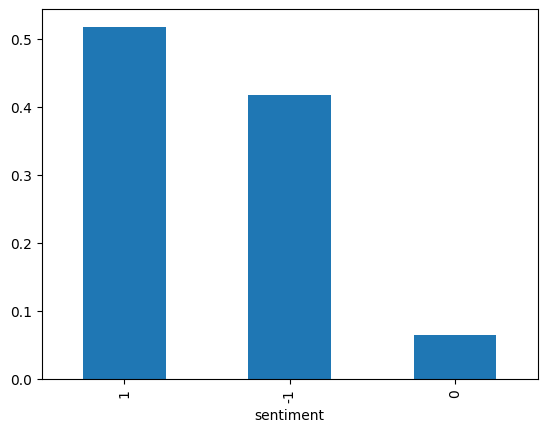

In [17]:
y.value_counts(normalize=True).plot(kind='bar');

In [18]:
class_indices = np.argmax(y_pred_prob, axis=1)
col_0 = y_pred_prob[:,0]
label_map = np.array([-1,0,1])
standard_labels = label_map[class_indices]
final_labels = np.where(col_0 > 0.8, -1, standard_labels)
print(final_labels)

[ 1  1 -1 ...  1  1 -1]


In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

acc = accuracy_score(y_pred, y_test)
print(acc)

0.7864385297845374


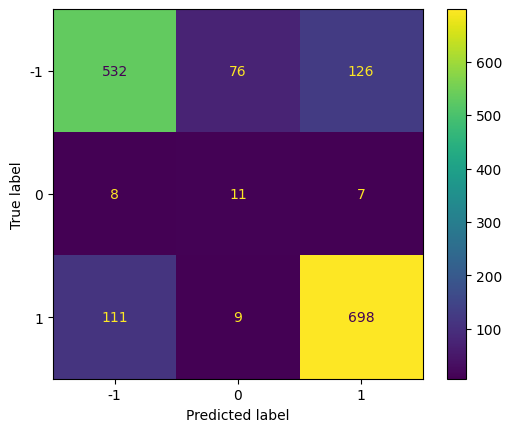

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_pred, y_test)
disp = ConfusionMatrixDisplay(cm, display_labels=log.classes_)
disp.plot();

In [21]:
y_test.value_counts()

sentiment
 1    831
-1    651
 0     96
Name: count, dtype: int64

In [22]:
from imblearn.over_sampling import SMOTE
os = SMOTE(random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)



In [ ]:
#machine learning model to predict product and sub product.

In [25]:
data[['category','subcategory']] = data['theme'].str.split(':',n=1,expand = True)  # n =1 means only split once,,expand  = True means pandas expands the result into separate columns: other wise it would give pandas series  

In [26]:
data[['theme','category','subcategory']].head(10)

,theme,category,subcategory
0,Product:General,Product,General
1,Product:Size / Fit,Product,Size / Fit
2,Product:Size / Fit,Product,Size / Fit
3,Product:Discounts / Promotions,Product,Discounts / Promotions
4,Product:Size / Fit,Product,Size / Fit
5,Brand:Satisfied / No Suggestions,Brand,Satisfied / No Suggestions
6,Product:Models / Photos,Product,Models / Photos
7,Online Experience:Other,Online Experience,Other
8,Payment:Payment Methods,Payment,Payment Methods
9,Brand:Satisfied / No Suggestions,Brand,Satisfied / No Suggestions


In [27]:
data['category'].value_counts()

category
Product              3540
Online Experience    1634
Delivery             1108
Brand                 685
Store                 424
Category Specific     248
Payment               205
Other                  22
Checkout               13
Test Rooms              9
Name: count, dtype: int64

In [28]:
data['subcategory'].value_counts()

subcategory
Delivery Speed / Timeliness       752
Size / Fit                        622
Range / Variety                   454
Price / Value for Money           424
Ease of Use / Order               420
Other                             414
General                           365
Information                       338
Quality                           338
Stock / Availability              332
Satisfied / No Suggestions        330
Discounts / Promotions            326
Models / Photos                   310
Returns                           296
Design / Style                    207
Children                          171
Search Function / Filters         148
Fabrics / Materials               115
Staff Attitude / Quality          109
Recommend                         106
Payment Methods                   101
Layout / Appearance                91
Membership / Club                  83
Delivery Price                     83
Payment Process                    75
Service Quality                    73


In [29]:
pd.crosstab(data['category'],data['subcategory'])

subcategory,Brand Satisfaction,Capacity,Children,Cleanliness,Colour,Competitor,Condition on Arrival,Courier,Customer Service,Delivery Price,...,Search Function / Filters,Self Scanning / Checkout,Service Quality,Shoes,Size / Fit,Staff Attitude / Quality,Staff-Customer Ratio,Stock / Availability,Wait Time / Queues,Womens
category,,,,,,,,,,,,,,,,,,,,,
Brand,57,0,0,0,0,25,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Category Specific,0,0,171,0,0,0,0,0,0,0,...,0,0,0,15,0,0,0,0,0,33
Checkout,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,2,0,0,7,0
Delivery,0,0,0,0,0,0,11,58,0,83,...,0,0,0,0,0,0,0,0,0,0
Online Experience,0,0,0,0,0,0,0,0,19,0,...,148,0,0,0,0,0,0,0,0,0
Other,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Payment,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Product,0,0,0,0,69,0,0,0,0,0,...,0,0,0,0,622,0,0,332,0,0
Store,0,8,0,0,0,0,0,0,0,0,...,0,0,73,0,0,107,5,0,39,0
